In [11]:
%pip install pandas  pyreadstat
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
  cross_val_score,StratifiedKFold, cross_validate)
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from scipy import stats
from sklearn.decomposition import PCA
import pyreadstat as py
from sklearn.metrics import (
    silhouette_score, accuracy_score,
    f1_score,mean_squared_error, r2_score,
    precision_score,
    recall_score,
    roc_auc_score,)
from sklearn.cluster import AgglomerativeClustering,  KMeans
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

# **1. Carga y limpieza de datos**


In [12]:
#Cargamos información y metadata
df,meta = py.read_dta("Base imputada EFH 2024.dta")

#Creamos un dataset de metadata
df_meta =pd.DataFrame({"Variable": meta.column_names,
                      "Descripcion": meta.column_labels})

df_meta

,Variable,Descripcion
0,imp,Identificador de imputación
1,id,Identificador de hogar
2,factor,Factor de expansión del hogar
3,genero_ent,Género del entrevistado
4,edad_ent,Edad del entrevistado en años
...,...,...
118,u_cheq,Uso de cheques
119,u_pat,Uso de PAT
120,u_transf,Uso de transferencias mediante internet o telé...
121,u_tprepago,Uso de tarjeta prepago


Al ser una base de imputación múltiple para variables continuas (ingresos, activos, pasivos), se tienen 31 bloques por hogar: base original sin imputar (imp=0) más 30 realizaciones (imp=1 a imp=30). En tal sentido, se filtrará por una sola realización imp == 1. Cada hogar aparece una única vez (id único), preservando la estructura IID (independiente e idénticamente distribuida) y evitando duplicar observaciones artificialmente.

In [13]:
df = df[df["imp"] == 1].copy()

In [14]:

# En encuestas de hogares, valores como 98, 99, 998, 999 suelen codificar "No sabe / No responde"
# Si bien la base imputada resuelve las variables financieras continuas, ciertas covariables
# sociodemográficas o categóricas pueden arrastrar estos códigos.
MISSING_CODES = [98, 99, 998, 999, -1]

# Identificar columnas a auditar
METADATA_COLS = ["id", "imp", "folio", "estrato", "zona", "fac_hog"]
LEAKAGE_COLS = [
    "ytoth",
    "ing_lab",
    "ing_pen",
    "ing_sub",
    "ing_cap",
    "ytrabajo",
    "yjubilacion",
]

feature_candidates = [
    c for c in df.columns if c not in METADATA_COLS + LEAKAGE_COLS
]

# Reemplazar códigos de no-respuesta por NaN en covariables categóricas/ordinales
for col in feature_candidates:
    if np.issubdtype(df[col].dtype, np.number):
        df[col] = df[col].replace(MISSING_CODES, np.nan)


df.head()

,imp,id,factor,genero_ent,edad_ent,tr_edad_ent,nacionalidad_ent,educ_ent,neduc_ent,est_civil_ent,...,u_efectivo,u_tdbto,u_tbco,u_tnbco,u_prepago,u_cheq,u_pat,u_transf,u_tprepago,u_pac
4649,1.0,10002.0,663.0,0.0,50.0,3.0,1.0,13.0,4.0,8.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4650,1.0,10003.0,880.0,1.0,68.0,4.0,1.0,7.0,1.0,8.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4651,1.0,10004.0,1028.0,0.0,40.0,2.0,1.0,12.0,2.0,8.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4652,1.0,10005.0,2380.0,0.0,38.0,2.0,12.0,16.0,4.0,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4653,1.0,10006.0,1025.0,1.0,50.0,3.0,1.0,17.0,4.0,8.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
df.shape

(4649, 123)

In [16]:

# Cálculo de porcentajes de completitud en las covariables candidatas
missing_stats = (
    pd.DataFrame(
        {
            "nulos": df[feature_candidates].isnull().sum(),
            "pct_nulos": (df[feature_candidates].isnull().mean() * 100).round(
                2
            ),
        }
    )
    .sort_values(by="pct_nulos", ascending=False)
    .query("pct_nulos > 0")
)


# Descarte de columnas con > 20% nulos
HIGH_NULL_COLS = missing_stats[
    missing_stats["pct_nulos"] > 20.0
].index.tolist()
features_kept = [c for c in feature_candidates if c not in HIGH_NULL_COLS]


# Consolidar todas las columnas a excluir
cols_to_exclude = set(METADATA_COLS + LEAKAGE_COLS + HIGH_NULL_COLS)

# -------------------------------------------------------------------------
# 2. Construir X_clean por exclusión
# -------------------------------------------------------------------------
# Se seleccionan todas las columnas que sobrevivieron a los filtros
feature_cols = [c for c in df.columns if c not in cols_to_exclude]

X_clean = df[feature_cols].copy()


In [17]:
# -------------------------------------------------------------------------
# TIPIFICACIÓN AUTOMÁTICA DE VARIABLES (NUMÉRICAS VS CATEGÓRICAS)
# -------------------------------------------------------------------------
# Criterio: variables numéricas continuas/discretas vs ordinales/nominales de baja cardinalidad
def devuelve_categoricas_numericas(df):
  numerical_cols = []
  categorical_cols = []

  for c in features_kept:
      if np.issubdtype(df[c].dtype, np.number):
          # Si tiene pocos valores únicos (<= 10), suele ser bandera binaria o código de categoría
          if df[c].nunique() <= 10:
              categorical_cols.append(c)
          else:
              numerical_cols.append(c)
      else:
          categorical_cols.append(c)
  return numerical_cols, categorical_cols

numerical_cols, categorical_cols = devuelve_categoricas_numericas(X_clean)
print(f"Numéricas continuas/conteos: {numerical_cols}")
print(f"Categóricas/indicadoras: {categorical_cols}")



Numéricas continuas/conteos: ['factor', 'edad_ent', 'nacionalidad_ent', 'educ_ent', 'edad_pr', 'nacionalidad_pr', 'educ_pr', 'numh', 'yoprinm_ent', 'yoprinm_pr', 'yoprin_ent', 'yoprin_pr', 'yosec_ent', 'yosec_pr', 'ylabh', 'ypenh', 'ysubh', 'yotroh', 'yai', 'ytotef', 'd_vp', 'd_otp', 'd_tothip', 'd_tcbco', 'd_lcbco', 'd_pbco', 'd_tcc', 'd_pcc', 'd_caco', 'd_auto', 'd_educ', 'd_otras', 'd_nhip', 'd_toth', 'act_vp', 'act_otp', 'act_vehic', 'act_otros', 'act_var', 'act_fijo', 'act_fin', 'act_ahcta', 'act_toth', 'div_vp', 'div_otp', 'cf_dhip', 'cf_dtbco', 'cf_dlbco', 'cf_dpbco', 'cf_dtcc', 'cf_dpcc', 'cf_dcaco', 'cf_dauto', 'cf_deduc', 'cf_dnhip', 'cf_dtoth', 'rci_dhip', 'rci_dnhip', 'rci_dt', 'rdi_dhip', 'rdi_dnhip', 'rdi_dt', 'cap_pen_ent']
Categóricas/indicadoras: ['genero_ent', 'tr_edad_ent', 'neduc_ent', 'est_civil_ent', 'ocup_ent', 'jub_ent', 'genero_pr', 'tr_edad_pr', 'neduc_pr', 'est_civil_pr', 'ocup_pr', 'jub_pr', 'macrozona', 'ocuph', 'tr_numh', 'reg_vp', 't_dhip', 't_tcbco', 't_

# **2. Aprendizaje Supervisado**


**Reducción** de dimensionalidad: Se implementa vía PCA dentro de los pipelines de modelos lineales para mitigar colinealidad y redundancia. En los modelos basados en árboles no es estrictamente necesario, pero se evalúa su impacto.

**Validación** cruzada: Se aplica KFold de 5 particiones (cv=5) encapsulado dentro de cada pipeline para prevenir fuga de información (data leakage).

In [23]:

# -------------------------------------------------------------------------
# DEFINICIÓN DEL TARGET: RIESGO DE SOBREENDEUDAMIENTO (RCI > 40%)
# -------------------------------------------------------------------------
# Supongamos cuota_financiera_mensual calculada o disponible en el DF
# y = 1 si la carga sobre el ingreso supera el 40%, 0 en caso contrario
rci = df["cf_dtoth"] / df["ytoth"]
y_class = (rci > 0.40).astype(int)

# Aislamiento de covariables predictoras (sin leakage de montos de deuda directa)
X_features = X_clean.copy()

# Partición Estratificada Train (80%) / Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_class, test_size=0.20, random_state=42, stratify=y_class
)

print(f"Dimensiones Train (80%): {X_train.shape[0]} observaciones")
print(f"Dimensiones Test  (20%): {X_test.shape[0]} observaciones")



Dimensiones Train (80%): 3719 observaciones
Dimensiones Test  (20%): 930 observaciones


In [24]:
def create_dim_reduction_pipeline(
    preprocessor: ColumnTransformer,
    method: str = "pca",
    n_components: float = 0.90,
    random_state: int = 42,
) -> Pipeline:

    if method.lower() == "pca":
        reduction_step = PCA(
            n_components=n_components, random_state=random_state
        )
    elif method.lower() == "passthrough":
        reduction_step = "passthrough"

    return Pipeline(
        steps=[("prep", preprocessor), ("dim_reduction", reduction_step)]
    )

In [25]:
def cv_results(models, X_train, y_train):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "roc_auc": "roc_auc",
        "f1": "f1",
        "precision": "precision",
        "recall": "recall",
        "accuracy": "accuracy",
    }

    fit_params = {}
    cv_records = []

    for name, pipeline in models.items():
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            params=fit_params,
            n_jobs=-1,
            return_train_score=False,
        )

        cv_records.append(
            {
                "Algoritmo": name,
                "ROC-AUC (CV)": np.mean(scores["test_roc_auc"]),
                "F1-Score (CV)": np.mean(scores["test_f1"]),
                "Precision (CV)": np.mean(scores["test_precision"]),
                "Recall (CV)": np.mean(scores["test_recall"]),
                "Accuracy (CV)": np.mean(scores["test_accuracy"]),
            }
        )

    return (
        pd.DataFrame(cv_records)
        .sort_values(by="ROC-AUC (CV)", ascending=False)
        .reset_index(drop=True)
    )

In [26]:
def test_results(models, X_train, y_train, X_test, y_test):
    test_records = []

    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        # Predicciones en Test
        y_pred = pipeline.predict(X_test)

        # Probabilidades para ROC-AUC
        if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:, 1]
        elif hasattr(pipeline.named_steps["classifier"], "decision_function"):
            y_proba = pipeline.decision_function(X_test)
        else:
            y_proba = y_pred

        test_records.append(
            {
                "Algoritmo": name,
                "ROC-AUC (Test)": roc_auc_score(
                    y_test, y_proba),
                "F1-Score (Test)": f1_score(
                    y_test, y_pred),
                "Precision (Test)": precision_score(
                    y_test, y_pred,  zero_division=0),
                "Recall (Test)": recall_score(
                    y_test, y_pred),
                "Accuracy (Test)": accuracy_score(
                    y_test, y_pred),
            }
        )

    return (
        pd.DataFrame(test_records)
        .sort_values(by="ROC-AUC (Test)", ascending=False)
        .reset_index(drop=True)
    )

In [27]:


# Asegurar que numéricas y categóricas cubran exactamente todas las columnas de X
num_features = [c for c in X_train.columns if c in numerical_cols]
cat_features = [c for c in X_train.columns if c in categorical_cols]

# 2. Definir los sub-pipelines con imputación obligatoria
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="first"
            ),
        ),
    ]
)

# ColumnTransformer: 'remainder="drop"' garantiza que cualquier columna extra no se cuele con NaNs
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features),
    ],
    remainder="drop",
)

#Modelos
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=150, class_weight="balanced", random_state=42
    ),
}

all_models = {}

# Variantes SIN PCA (el paso 'dim_red' no hace nada, pasa la matriz imputada tal cual)
for name, clf in classifiers.items():
    all_models[f"{name} (Sin PCA)"] = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("dim_red", "passthrough"),
            ("classifier", clf),
        ]
    )

# Variantes CON PCA (aplica PCA sobre la matriz ya imputada y escalada)
for name, clf in classifiers.items():
    all_models[f"{name} (Con PCA 90%)"] = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("dim_red", PCA(n_components=0.90, random_state=42)),
            ("classifier", clf),
        ]
    )
# -------------------------------------------------------------------------
# EJECUCIÓN Y GENERACIÓN DE MATRICES COMPARATIVAS
# -------------------------------------------------------------------------
# 1. Matriz de Validación Cruzada en Train
df_cv_results = cv_results(all_models,X_train, y_train)


# 2. Matriz de Evaluación Out-of-Sample en Test
df_test_results = test_results(all_models,X_train, y_train, X_test, y_test)


print("=" * 95)
print(
    "   1. MATRIZ DE DESEMPEÑO EN ENTRENAMIENTO (5-FOLD STRATIFIED CV / TRAIN)"
)
print("=" * 95)
print(df_cv_results)

print("\n" + "=" * 95)
print("   2. MATRIZ DE DESEMPEÑO GENERALIZADO (HOLDOUT / TEST 20%)")
print("=" * 95)
print(df_test_results)

   1. MATRIZ DE DESEMPEÑO EN ENTRENAMIENTO (5-FOLD STRATIFIED CV / TRAIN)
                            Algoritmo  ROC-AUC (CV)  F1-Score (CV)  \
0      HistGradientBoosting (Sin PCA)      0.998341       0.953808   
1       Logistic Regression (Sin PCA)      0.996405       0.920497   
2             Random Forest (Sin PCA)      0.995884       0.922742   
3   Logistic Regression (Con PCA 90%)      0.995315       0.907763   
4  HistGradientBoosting (Con PCA 90%)      0.983736       0.829992   
5         Random Forest (Con PCA 90%)      0.972184       0.770664   

   Precision (CV)  Recall (CV)  Accuracy (CV)  
0        0.942430     0.966214       0.986557  
1        0.870055     0.977429       0.975800  
2        0.926593     0.919273       0.977951  
3        0.856206     0.966267       0.971767  
4        0.848553     0.814354       0.952406  
5        0.813931     0.735426       0.937348  

   2. MATRIZ DE DESEMPEÑO GENERALIZADO (HOLDOUT / TEST 20%)
                            Algoritmo 

# **3. Aprendizaje no Supervisado**
Balanceo de clases: No existe ni aplica en modelos no supervisados, ya que no hay clases predefinidas ni variables objetivo a equilibrar.

Reducción de dimensionalidad: Es indispensable. Tras aplicar One-Hot Encoding, la matriz se vuelve de alta dimensión y rala (curse of dimensionality), lo cual distorsiona las distancias euclidianas. Reducir con PCA o TruncatedSVD estabiliza métricas geométricas como distancias inter-cluster.



In [28]:
# Usar X_clean definido previamente
X_unsupervised = X_clean.copy()

num_features = [c for c in X_unsupervised.columns if c in numerical_cols]
cat_features = [c for c in X_unsupervised.columns if c in categorical_cols]

# Imputación y escalado de covariables
num_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="first"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop",
)

In [31]:
#Aquí se ejecuta el fit_transform de todo el pipeline de datos
X_processed = preprocessor.fit_transform(X_unsupervised)

# Reducción de dimensionalidad: retiene el 85% de la varianza explicada
pca = PCA(n_components=0.85, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"Dimensiones tras One-Hot: {X_processed.shape[1]} columnas")
print(
    f"Dimensiones tras PCA (85% varianza): {X_pca.shape[1]} componentes ortogonales"
)

Dimensiones tras One-Hot: 158 columnas
Dimensiones tras PCA (85% varianza): 38 componentes ortogonales


In [32]:

N_CLUSTERS = 4
models = {
    "K-Means (Centroides)": KMeans(
        n_clusters=N_CLUSTERS, n_init=10, random_state=42
    ),
    "Agglomerative (Jerárquico Ward)": AgglomerativeClustering(
        n_clusters=N_CLUSTERS, linkage="ward"
    ),
}

In [38]:
N_SPLITS = 5
SAMPLE_RATIO = 0.80  # Evaluar en el 80% de la muestra por fold
rng = np.random.RandomState(42)

results = []

for name, model in models.items():
    sil_scores, ch_scores, db_scores = [], [], []

    for fold in range(N_SPLITS):
        # Muestreo sin reemplazo para probar robustez estructural
        idx = rng.choice(
            len(X_pca), size=int(len(X_pca) * SAMPLE_RATIO), replace=False
        )
        X_sample = X_pca[idx]

        # AQUÍ SE EJECUTA EL FIT Y PREDICT DE CADA ALGORITMO
        labels = model.fit_predict(X_sample)

        if len(np.unique(labels)) < 2:
            continue

        # Métricas geométricas no supervisadas
        sil = silhouette_score(
            X_sample,
            labels,
            metric="euclidean",
            sample_size=min(2500, len(X_sample)),
            random_state=42,
        )
        #ch = calinski_harabasz_score(X_sample, labels)
        #db = davies_bouldin_score(X_sample, labels)

        sil_scores.append(sil)
        #ch_scores.append(ch)
        #db_scores.append(db)

    results.append(
        {
            "Algoritmo": name,
            "Silhouette (↑)": np.mean(sil_scores),
            "Desv. Sil": np.std(sil_scores),
            #"Calinski-Harabasz (↑)": np.mean(ch_scores),
            #"Davies-Bouldin (↓)": np.mean(db_scores),
        }
    )

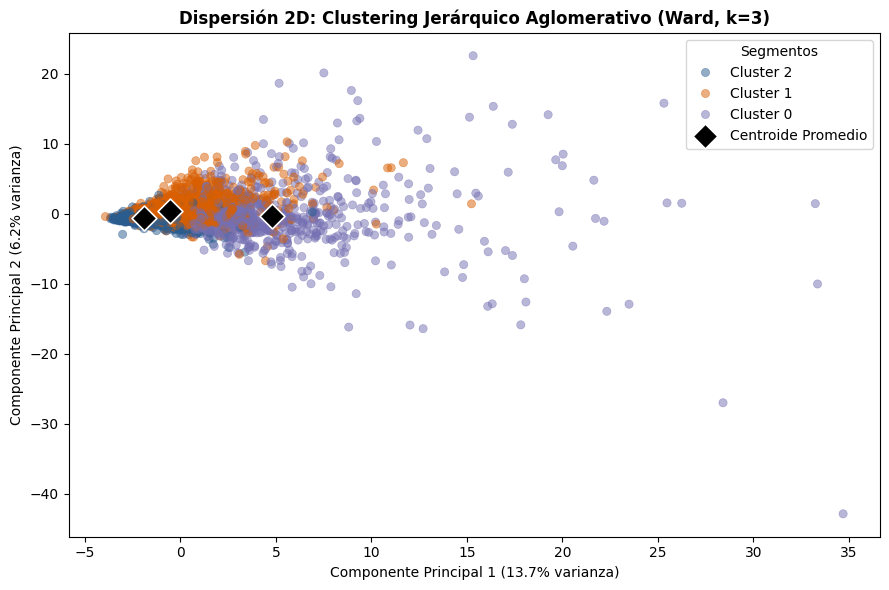

In [39]:


# 1. Ajuste del modelo jerárquico sobre el espacio PCA de 2 dimensiones
K = 3
agg_model = AgglomerativeClustering(n_clusters=K, linkage="ward")
agg_labels = agg_model.fit_predict(X_pca)

# 2. DataFrame para visualización
df_agg_plot = pd.DataFrame(
    {
        "PCA1": X_pca[:, 0],
        "PCA2": X_pca[:, 1],
        "Cluster": [f"Cluster {c}" for c in agg_labels],
    }
)

# 3. Calcular centroides empíricos para referencia visual
centroids_agg = (
    df_agg_plot.groupby("Cluster")[["PCA1", "PCA2"]].mean().values
)

# 4. Gráfico de dispersión
plt.figure(figsize=(9, 6))
palette = ["#2b5c8f", "#d95f02", "#7570b3"]

sns.scatterplot(
    data=df_agg_plot,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette=palette,
    alpha=0.5,
    s=35,
    edgecolor=None,
)

# Marcadores de centroides promedio
plt.scatter(
    centroids_agg[:, 0],
    centroids_agg[:, 1],
    c="black",
    s=160,
    marker="D",
    edgecolors="white",
    linewidths=1.2,
    label="Centroide Promedio",
    zorder=10,
)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title(
    f"Dispersión 2D: Clustering Jerárquico Aglomerativo (Ward, k={K})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(f"Componente Principal 1 ({var_pc1:.1f}% varianza)")
plt.ylabel(f"Componente Principal 2 ({var_pc2:.1f}% varianza)")
plt.legend(title="Segmentos", loc="best", frameon=True)
plt.tight_layout()
plt.show()

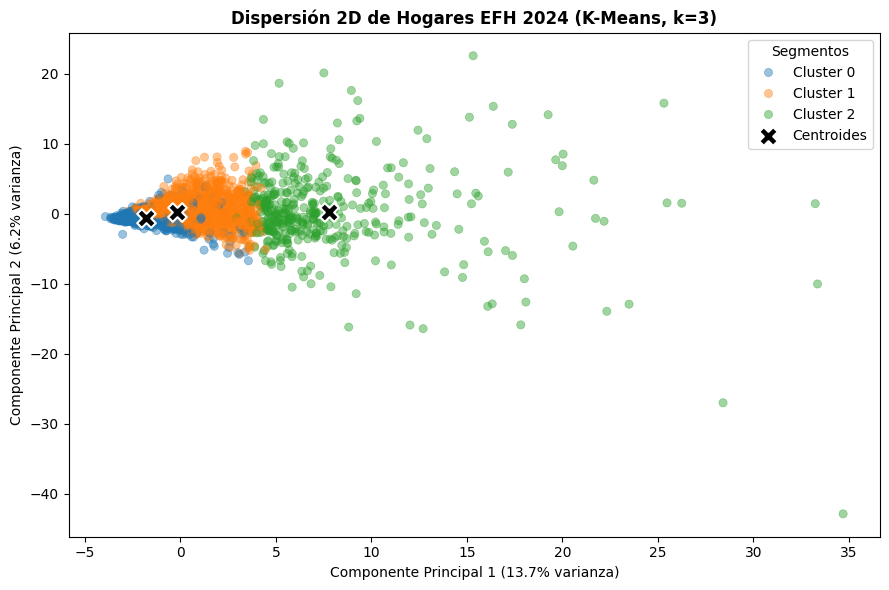

In [40]:


# -------------------------------------------------------------------------
# AJUSTE DE K-MEANS SOBRE EL ESPACIO PCA
# -------------------------------------------------------------------------
# X_pca2 corresponde a la matriz de 2 dimensiones generada en el paso previo
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

# DataFrame auxiliar para graficar
df_plot = pd.DataFrame(
    {
        "PCA1": X_pca[:, 0],
        "PCA2": X_pca[:, 1],
        "Cluster": [f"Cluster {c}" for c in cluster_labels],
    }
)

# -------------------------------------------------------------------------
# VISUALIZACIÓN DE CLUSTERS Y CENTROIDES
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 6))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Gráfico de dispersión de las observaciones
sns.scatterplot(
    data=df_plot,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette=palette,
    alpha=0.45,
    s=35,
    edgecolor=None,
)

# Posicionamiento de los centroides de cada cluster
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    s=180,
    marker="X",
    linewidths=1.5,
    edgecolors="white",
    label="Centroides",
    zorder=10,
)

# Varianza explicada por cada componente principal (obtenida del objeto pca previo)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title(
    f"Dispersión 2D de Hogares EFH 2024 (K-Means, k={K})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(f"Componente Principal 1 ({var_pc1:.1f}% varianza)")
plt.ylabel(f"Componente Principal 2 ({var_pc2:.1f}% varianza)")
plt.legend(title="Segmentos", loc="best", frameon=True)
plt.tight_layout()
plt.show()

In [43]:
df_analisis = df.copy()
df_analisis["cluster"] = cluster_labels

# Resumen socioeconómico y financiero por cluster
resumen_clusters = (
    df_analisis.groupby("cluster")
    .agg(
        total_hogares=("id", "count"),
        porc_muestra=("id", lambda x: f"{len(x) / len(df_analisis) * 100:.1f}%"),
        ingreso_mediano=("ytoth", "median"),
        edad_promedio=("edad_ent", "mean"),
        tamano_hogar=("numh", "mean"),
        ocupados_promedio=("ocuph", "mean"),
        tienen_hipoteca=("t_dhip","mean",),  # % del cluster con hipoteca
        tienen_cta_cte=("t_cc", "mean"),  # % con cuenta corriente
        tienen_tc_banco=("t_tbco", "mean"),  # % con tarjeta banco
    )
    .round(2)
)

print(resumen_clusters)

         total_hogares porc_muestra  ingreso_mediano  edad_promedio  \
cluster                                                               
0                 1540        33.1%        1029500.0          66.04   
1                 2693        57.9%        1700000.0          41.40   
2                  416         8.9%        5600000.0          47.88   

         tamano_hogar  ocupados_promedio  tienen_hipoteca  tienen_cta_cte  \
cluster                                                                     
0                2.36               0.84             0.04            0.24   
1                2.87               1.52             0.18            0.59   
2                3.11               1.77             0.79            0.96   

         tienen_tc_retail  
cluster                    
0                    0.18  
1                    0.41  
2                    0.86  
